In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('kz.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (2633521, 8)
                event_time             order_id           product_id  \
0  2020-04-24 11:50:39 UTC  2294359932054536986  1515966223509089906   
1  2020-04-24 11:50:39 UTC  2294359932054536986  1515966223509089906   
2  2020-04-24 14:37:43 UTC  2294444024058086220  2273948319057183658   
3  2020-04-24 14:37:43 UTC  2294444024058086220  2273948319057183658   
4  2020-04-24 19:16:21 UTC  2294584263154074236  2273948316817424439   

    category_id                category_code    brand   price       user_id  
0  2.268105e+18           electronics.tablet  samsung  162.01  1.515916e+18  
1  2.268105e+18           electronics.tablet  samsung  162.01  1.515916e+18  
2  2.268105e+18  electronics.audio.headphone   huawei   77.52  1.515916e+18  
3  2.268105e+18  electronics.audio.headphone   huawei   77.52  1.515916e+18  
4  2.268105e+18                          NaN  karcher  217.57  1.515916e+18  


In [2]:
# Data Cleaning
print("Missing values:")
print(df.isnull().sum())

print("\nColumn names:", df.columns.tolist())
print("\nData types:", df.dtypes)

Missing values:
event_time             0
order_id               0
product_id             0
category_id       431954
category_code     612202
brand             506005
price             431954
user_id          2069352
dtype: int64

Column names: ['event_time', 'order_id', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id']

Data types: event_time        object
order_id           int64
product_id         int64
category_id      float64
category_code     object
brand             object
price            float64
user_id          float64
dtype: object


In [3]:
# Cleaning
df = df.dropna(subset=['category_code', 'brand'])
df = df[df['price'] > 0]

print("Cleaned shape:", df.shape)
print("Unique orders:", df['order_id'].nunique())
print("Unique products:", df['product_id'].nunique())
print("\nTop categories:")
print(df['category_code'].value_counts().head(10))

Cleaned shape: (1532150, 8)
Unique orders: 1143379
Unique products: 13160

Top categories:
category_code
electronics.smartphone              352534
appliances.kitchen.refrigerators     76742
electronics.video.tv                 71709
computers.notebook                   71227
appliances.environment.vacuum        66231
electronics.audio.headphone          65234
appliances.kitchen.kettle            57968
appliances.kitchen.washer            54119
furniture.kitchen.table              46693
appliances.iron                      39141
Name: count, dtype: int64


In [4]:
# Speed এর জন্য sample নাও
df_sample = df.sample(n=50000, random_state=42)

# Basket Matrix
basket = df_sample.groupby(['order_id', 'category_code'])['product_id']\
         .count().unstack().fillna(0)

# 0 আর 1 করো
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print("Basket shape:", basket.shape)
print(basket.head())

Basket shape: (49387, 111)
category_code        accessories.bag  apparel.glove  apparel.shirt  \
order_id                                                             
2297989017720849297                0              0              0   
2297991320922226852                0              0              0   
2298045970010604429                0              0              0   
2298173760605257768                0              0              0   
2298474283074060293                0              0              0   

category_code        apparel.sock  apparel.trousers  apparel.tshirt  \
order_id                                                              
2297989017720849297             0                 0               0   
2297991320922226852             0                 0               0   
2298045970010604429             0                 0               0   
2298173760605257768             0                 0               0   
2298474283074060293             0                 0     

In [5]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Frequent Itemsets
frequent_itemsets = apriori(basket, 
                            min_support=0.02, 
                            use_colnames=True)

# Association Rules
rules = association_rules(frequent_itemsets, 
                          metric='lift', 
                          min_threshold=1.0)

rules = rules.sort_values('lift', ascending=False)

print("Total rules found:", len(rules))
print("\nTop 10 Rules:")
print(rules[['antecedents','consequents',
             'support','confidence','lift']].head(10))

Total rules found: 0

Top 10 Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


C:\Users\kazis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [6]:
import sys
!{sys.executable} -m pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\kazis\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import os

os.chdir('E:/')
df = pd.read_csv('kz.csv')
df = df.dropna(subset=['category_code'])
df = df[df['price'] > 0]

# Category কে সহজ করো (শুধু main category নাও)
df['main_category'] = df['category_code'].apply(lambda x: x.split('.')[0])

# বড় sample নাও
df_sample = df.sample(n=100000, random_state=42)

# Basket বানাও main category দিয়ে
basket = df_sample.groupby(['order_id', 'main_category'])['product_id']\
         .count().unstack().fillna(0)

basket = (basket > 0)  # Boolean

print("Basket shape:", basket.shape)
print("Categories:", basket.columns.tolist())
print("\nCo-purchase counts:")
print((basket.sum()))

Basket shape: (97485, 13)
Categories: ['accessories', 'apparel', 'appliances', 'auto', 'computers', 'construction', 'country_yard', 'electronics', 'furniture', 'kids', 'medicine', 'sport', 'stationery']

Co-purchase counts:
main_category
accessories       811
apparel           499
appliances      37488
auto              187
computers       13801
construction      816
country_yard       22
electronics     34110
furniture        7517
kids              323
medicine          200
sport             136
stationery       2508
dtype: int64


In [2]:
from mlxtend.frequent_patterns import apriori, association_rules

# Apriori run করো
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
print("Frequent itemsets found:", len(frequent_itemsets))

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print("\nTotal rules found:", len(rules))
print("\n🔥 Top 10 Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

Frequent itemsets found: 5

Total rules found: 0

🔥 Top 10 Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [3]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
print("Frequent itemsets found:", len(frequent_itemsets))

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print("Total rules found:", len(rules))
print("Top 10 Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

Frequent itemsets found: 5
Total rules found: 0
Top 10 Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [4]:
import pandas as pd
import os

os.chdir('E:/')
df = pd.read_csv('kz.csv')
df = df.dropna(subset=['category_code', 'user_id'])
df = df[df['price'] > 0]

df['main_category'] = df['category_code'].apply(lambda x: x.split('.')[0])

# order_id এর বদলে user_id দিয়ে basket বানাও
basket = df.groupby(['user_id', 'main_category'])['product_id']\
         .count().unstack().fillna(0)

basket = (basket > 0)

print("Basket shape:", basket.shape)

from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)
print("Frequent itemsets found:", len(frequent_itemsets))

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print("Total rules found:", len(rules))
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

Basket shape: (91619, 13)
Frequent itemsets found: 9
Total rules found: 8
                 antecedents                consequents   support  confidence  \
0               (appliances)                (furniture)  0.053592    0.115616   
1                (furniture)               (appliances)  0.053592    0.675936   
2  (appliances, electronics)                (computers)  0.079721    0.376030   
7                (computers)  (appliances, electronics)  0.079721    0.273794   
5               (appliances)   (electronics, computers)  0.079721    0.171988   
4   (electronics, computers)               (appliances)  0.079721    0.546134   
3    (appliances, computers)              (electronics)  0.079721    0.660816   
6              (electronics)    (appliances, computers)  0.079721    0.130557   

       lift  
0  1.458241  
1  1.458241  
2  1.291429  
7  1.291429  
5  1.178211  
4  1.178211  
3  1.082193  
6  1.082193  


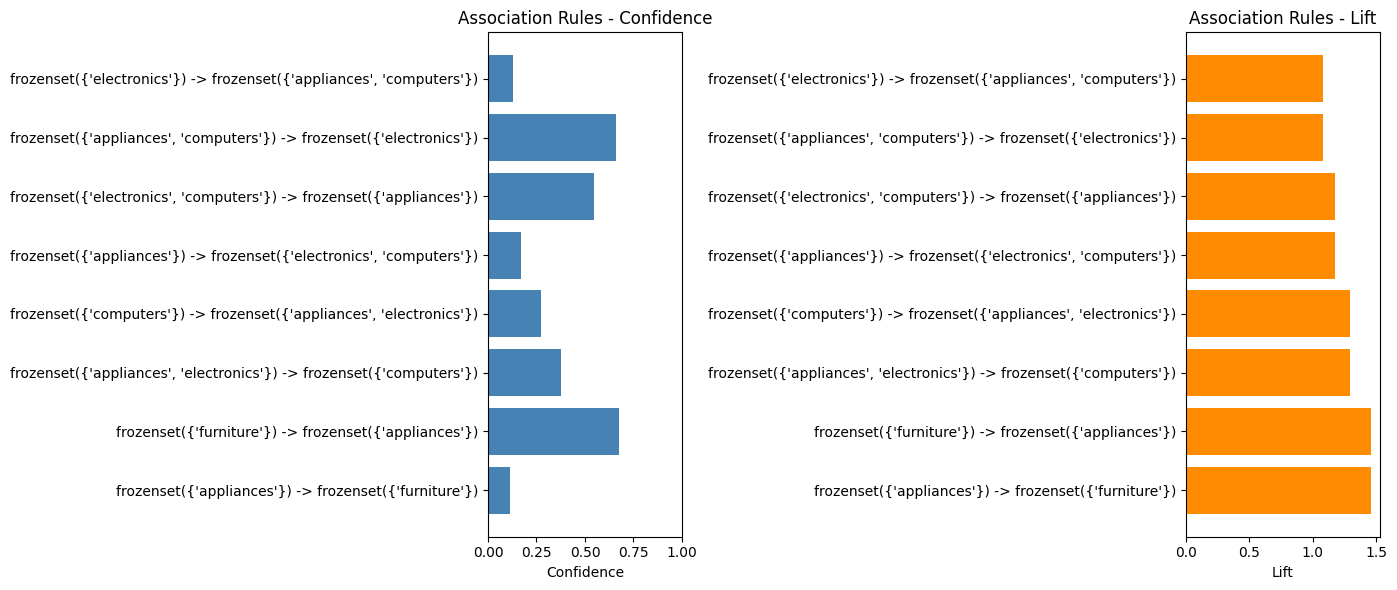

Chart saved!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Confidence
rules_plot = rules.copy()
rules_plot['rule'] = rules_plot['antecedents'].astype(str) + ' -> ' + rules_plot['consequents'].astype(str)

axes[0].barh(rules_plot['rule'], rules_plot['confidence'], color='steelblue')
axes[0].set_xlabel('Confidence')
axes[0].set_title('Association Rules - Confidence')
axes[0].set_xlim(0, 1)

# Chart 2: Lift
axes[1].barh(rules_plot['rule'], rules_plot['lift'], color='darkorange')
axes[1].set_xlabel('Lift')
axes[1].set_title('Association Rules - Lift')

plt.tight_layout()
plt.savefig('market_basket_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [6]:
print("=" * 60)
print("MARKET BASKET ANALYSIS - FINAL SUMMARY")
print("=" * 60)
print(f"Total Users Analyzed: {basket.shape[0]:,}")
print(f"Total Categories: {basket.shape[1]}")
print(f"Association Rules Found: {len(rules)}")
print()
print("TOP BUSINESS INSIGHTS:")
print("-" * 60)
for i, row in rules.head(5).iterrows():
    ant = str(row['antecedents']).replace("frozenset({", "").replace("})", "").replace("'", "")
    con = str(row['consequents']).replace("frozenset({", "").replace("})", "").replace("'", "")
    print(f"- Users who buy {ant}")
    print(f"  -> {row['confidence']*100:.1f}% chance they also buy {con}")
    print(f"  -> Lift: {row['lift']:.2f}")
    print()

MARKET BASKET ANALYSIS - FINAL SUMMARY
Total Users Analyzed: 91,619
Total Categories: 13
Association Rules Found: 8

TOP BUSINESS INSIGHTS:
------------------------------------------------------------
- Users who buy appliances
  -> 11.6% chance they also buy furniture
  -> Lift: 1.46

- Users who buy furniture
  -> 67.6% chance they also buy appliances
  -> Lift: 1.46

- Users who buy appliances, electronics
  -> 37.6% chance they also buy computers
  -> Lift: 1.29

- Users who buy computers
  -> 27.4% chance they also buy appliances, electronics
  -> Lift: 1.29

- Users who buy appliances
  -> 17.2% chance they also buy electronics, computers
  -> Lift: 1.18

